In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#load data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#data cleanup
df['job_posted_date'] =pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\ADMIN\anaconda3\envs\python_4_data_analytics\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df =df[df['job_title_short'] == 'Data Analyst']

In [4]:
df_exploded = df.explode('job_skills')

In [10]:
skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)
skills_stats = skill_stats.sort_values(by='skill_count',ascending =False).head(10)

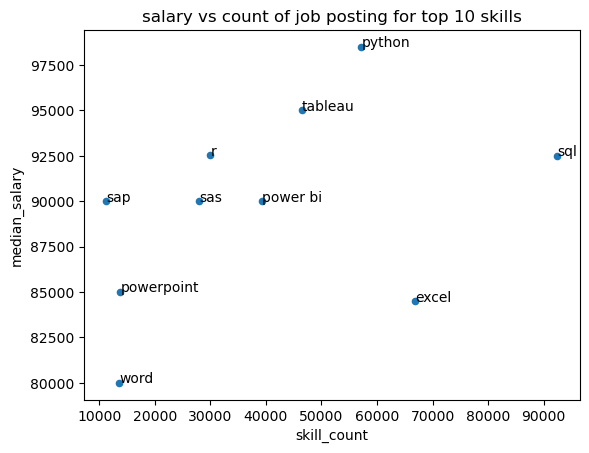

In [ ]:
skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.title('salary vs count of job posting for top 10 skills')

for i,txt in enumerate(skills_stats.index):# get name and salary for each dot from df skills_stats
    plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)
plt.show()

